In [1]:
from torch_snippets import *
from torchvision.datasets import MNIST
from torchvision import transforms


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
img_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5]),
    transforms.Lambda(lambda x: x.to(device))
])# faz a normalizaçaõ da imagens junto a transformar em tensor

In [4]:
trn_ds = MNIST('./data', transform=img_transforms, train=True, download=True) # aplica o transformers ao dowload do dataset
val_ds = MNIST('./data', transform=img_transforms, train=True, download=True)

In [ ]:
batch_size = 256
trn_dl = DataLoader(trn_ds, batch_size=batch_size, shuffle=True)
val_dl = DataLoader(val_ds, batch_size=batch_size, shuffle=False)# define o tamanho os batchs 

In [10]:
class AutoEncoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.latend_dim = latent_dim # define por parametro o quao pequeno fica a imagem comprimida
        self.encoder = nn.Sequential(# no encoder, ele vai comprimindo a imagem ou seja diminuindo os pixels 
            nn.Linear(28 * 28, 128), nn.ReLU(True),
            nn.Linear(128, 64), nn.ReLU(True),
            nn.Linear(64, latent_dim))
        self.decoder = nn.Sequential( # no decoder volta a imagem como era
            nn.Linear(latent_dim, 12), nn.ReLU(True),
            nn.Linear(12,64), nn.ReLU(True),
            nn.Linear(64, 128), nn.ReLU(True),
            nn.Linear(128, 28 * 28), nn.Tanh()
            )
        
    def forward(self, x):
        x = x.view(len(x), -1)
        x = self.encoder(x)# comprime a imagem
        x = self.decoder(x)# volta a imagem como era
        x = x.view(len(x), 1, 28, 28)# tamanho original
        return x

In [ ]:
def train_batch(input, model, criterion, optimizer):# treino padrao utilizado ate agora
    model.train()
    optimizer.zero_grad()
    output = model(input)
    
    loss = criterion(output, input)
    loss.backward()
    optimizer.step()
    return loss


@torch.no_grad() # avalia o modelo
def validate_batch(input, model, criterion):
    model.eval()
    output = model(input)
    loss = criterion(output, input)
    return loss

EPOCH: 1.000  val_loss: 0.205  trn_loss: 0.271  (11.02s - 44.08s remaining)
EPOCH: 2.000  val_loss: 0.177  trn_loss: 0.191  (22.44s - 33.65s remaining)
EPOCH: 3.000  val_loss: 0.164  trn_loss: 0.170  (35.37s - 23.58s remaining)
EPOCH: 4.000  val_loss: 0.158  trn_loss: 0.161  (45.06s - 11.27s remaining)
EPOCH: 5.000  val_loss: 0.154  trn_loss: 0.156  (54.26s - 0.00s remaining)


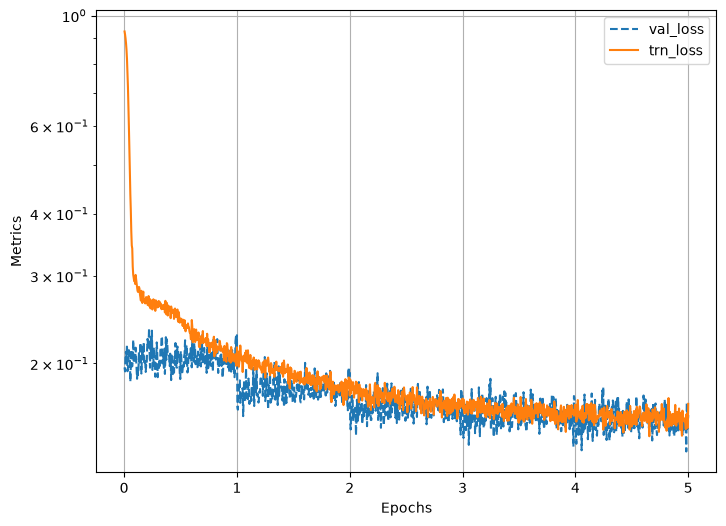

In [12]:
model = AutoEncoder(3).to(device) # cria o autoencoder com 3 latent_dim
criterion = nn.MSELoss()# loss em MEan Squared Error
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)

num_epochs = 5
log = Report(num_epochs)

for epoch in range(num_epochs):
    N = len(trn_dl)
    for ix, (data, _) in enumerate(trn_dl):
        loss = train_batch(data, model, criterion, optimizer)
        log.record(pos=(epoch + (ix+1)/N), trn_loss=loss, end='\r')

    N = len(val_dl)
    for ix, (data, _) in enumerate(val_dl): # registra no grafico o loss do batch treinado
        loss = validate_batch(data, model, criterion)
        log.record(pos=(epoch + (ix+1)/N), val_loss=loss, end='\r')
    log.report_avgs(epoch+1)
log.plot(log=True)

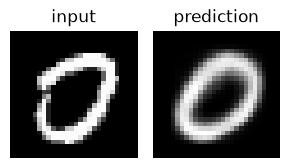

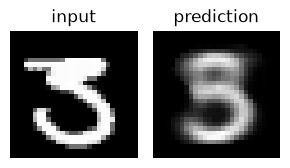

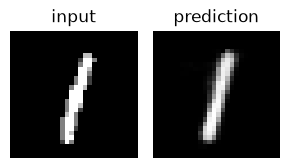

In [ ]:
import matplotlib.pyplot as plt
# mostra antes e epois do encoder, podemos ver que a diferença entre as duas é nitida para o olho humano
for _ in range(3):
    ix = np.random.randint(len(val_ds))
    im, _ = val_ds[ix]
    _im = model(im[None])[0]
    fig, ax = plt.subplots(1,2,figsize=(3,3))
    show(im[0], ax=ax[0], title='input')
    show(_im[0], ax=ax[1], title='prediction')
    plt.tight_layout()
    plt.show()